# Combined Yellow Taxi + HVFHV Spark Iceberg EDA

This notebook analyzes total NYC ride demand across Yellow Taxi and High Volume For-Hire Vehicle (HVFHV) trips from the project Iceberg tables.

Main focus:
- use Spark and Iceberg tables instead of CSV or Pandas
- keep source-level checks for cleaning and data quality
- aggregate both services together for citywide demand, time, geography, trip-metric, and holiday EDA graphs


## 1. Start Spark

The notebook reads the Iceberg warehouse created by `jobs/build_taxi_demand_ml_to_iceberg.py`. Run it from the Spark container when possible so HDFS service names resolve directly. If you run from VS Code on your Mac, the Spark config below tells HDFS to use the exposed DataNode hostname instead of the Docker-internal DataNode IP.

The project Spark image installs `matplotlib`, `pandas`, and `seaborn` for notebook charts. Spark still performs the table scans and aggregations; Pandas is only used for small plotting samples after Spark has reduced the data. If an older running container still says one of these packages is missing, rebuild and restart the Spark services from the project root.

If the kernel already has a Spark session with different catalog settings, this cell restarts it before applying the Iceberg configuration.


In [1]:
from pathlib import Path

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
except ModuleNotFoundError:
    mdates = None
    plt = None
    FuncFormatter = None

from pyspark import SparkContext
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

ICEBERG_PACKAGE = "org.apache.iceberg:iceberg-spark-runtime-3.5_2.12:1.5.2"
RUNNING_IN_DOCKER = Path("/workspace").exists()

ICEBERG_WAREHOUSE = (
    "hdfs://namenode:9000/user/data/warehouse"
    if RUNNING_IN_DOCKER
    else "hdfs://localhost:9000/user/data/warehouse"
)
USE_DATANODE_HOSTNAME = "false" if RUNNING_IN_DOCKER else "true"

ML_TABLE = "nyc.taxi_demand_ml"
EDA_TABLES = {
    "cleaning_summary": "nyc.eda_cleaning_summary",
    "curated_feature_profile": "nyc.eda_curated_feature_profile",
    "overall_hourly_demand": "nyc.eda_overall_hourly_demand",
    "borough_hourly_demand": "nyc.eda_borough_hourly_demand",
    "weekday_weekend_demand": "nyc.eda_weekday_weekend_demand",
    "weekday_hourly_demand": "nyc.eda_weekday_hourly_demand",
    "trip_metrics_by_hour": "nyc.eda_trip_metrics_by_hour",
    "top_pickup_zones": "nyc.eda_top_pickup_zones",
    "top_dropoff_zones": "nyc.eda_top_dropoff_zones",
}
SOURCE_ORDER = ["yellow", "hvfhv"]
SOURCE_LABELS = {"yellow": "Yellow Taxi", "hvfhv": "HVFHV"}
SOURCE_COLORS = {"yellow": "#f59e0b", "hvfhv": "#2563eb"}

active_session = SparkSession.getActiveSession()
if active_session is not None:
    active_session.stop()
elif SparkContext._active_spark_context is not None:
    SparkContext._active_spark_context.stop()

spark = (
    SparkSession.builder
    .appName("Yellow Taxi and HVFHV Iceberg EDA")
    .master("local[*]")
    .config("spark.jars.packages", ICEBERG_PACKAGE)
    .config("spark.sql.catalog.nyc", "org.apache.iceberg.spark.SparkCatalog")
    .config("spark.sql.catalog.nyc.type", "hadoop")
    .config("spark.sql.catalog.nyc.warehouse", ICEBERG_WAREHOUSE)
    .config("spark.hadoop.dfs.client.use.datanode.hostname", USE_DATANODE_HOSTNAME)
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
    .config("spark.sql.shuffle.partitions", "12")
    .config("spark.default.parallelism", "12")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

if plt is not None:
    plt.style.use("seaborn-v0_8-whitegrid")
else:
    print("matplotlib is not installed in this kernel; Spark table outputs will still run.")
print(f"Iceberg warehouse: {ICEBERG_WAREHOUSE}")
print(f"Use DataNode hostname: {USE_DATANODE_HOSTNAME}")


:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/spark/.ivy2/cache
The jars for the packages stored in: /home/spark/.ivy2/jars
org.apache.iceberg#iceberg-spark-runtime-3.5_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f2b34852-6cbc-440b-8cc3-6288ce23ced4;1.0
	confs: [default]
	found org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.5.2 in central
:: resolution report :: resolve 35ms :: artifacts dl 1ms
	:: modules in use:
	org.apache.iceberg#iceberg-spark-runtime-3.5_2.12;1.5.2 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   1   |   0   |   0   |   0   ||   1   |   0   |
	---------------------------------------------------------------------
:: retrieving :: org.apache.spark

Iceberg warehouse: hdfs://namenode:9000/user/data/warehouse
Use DataNode hostname: false


## 2. Load Iceberg Tables

The ML table is the combined demand dataset. The EDA tables keep source fields, but the main demand analysis below sums Yellow Taxi and HVFHV together before plotting.


In [2]:
def require_columns(df, table_name, required_columns):
    missing = [column for column in required_columns if column not in df.columns]
    if missing:
        raise ValueError(f"{table_name} is missing required columns: {missing}")


def read_table(table_name):
    df = spark.read.table(table_name)
    if df.limit(1).count() == 0:
        raise ValueError(f"{table_name} has no rows")
    return df


ml_df = read_table(ML_TABLE)
eda = {name: read_table(table_name) for name, table_name in EDA_TABLES.items()}

require_columns(
    ml_df,
    ML_TABLE,
    [
        "source_id",
        "source_name",
        "PULocationID",
        "pickup_date",
        "pickup_year",
        "pickup_month",
        "pickup_day_of_week",
        "pickup_hour",
        "is_weekend",
        "trip_count",
    ],
)

print(f"Loaded {ML_TABLE}")
ml_df.printSchema()

source_totals = (
    ml_df.groupBy("source_id", "source_name")
    .agg(
        F.count("*").alias("hour_zone_rows"),
        F.sum("trip_count").cast("long").alias("total_trips"),
        F.min("pickup_date").alias("first_pickup_date"),
        F.max("pickup_date").alias("last_pickup_date"),
    )
    .orderBy("source_id")
)
source_totals.show(truncate=False)


Loaded nyc.taxi_demand_ml
root
 |-- source_id: integer (nullable = true)
 |-- source_name: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- pickup_date: date (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_day: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_day_of_week: integer (nullable = true)
 |-- is_weekend: boolean (nullable = true)
 |-- trip_count: long (nullable = true)



+---------+-----------+--------------+-----------+-----------------+----------------+
|source_id|source_name|hour_zone_rows|total_trips|first_pickup_date|last_pickup_date|
+---------+-----------+--------------+-----------+-----------------+----------------+
|0        |yellow     |2633903       |105881725  |2023-01-01       |2025-12-31      |
|1        |hvfhv      |6632392       |714751993  |2023-01-01       |2025-12-31      |
+---------+-----------+--------------+-----------+-----------------+----------------+



## 3. Reusable Spark Chart Helpers

Spark performs the grouping and ordering. The helper functions only collect small aggregated results for visualization.

If `matplotlib` is unavailable, the notebook still prints Spark tables and skips only the charts.


In [3]:
def collect_rows(df, limit=None):
    selected = df.limit(limit) if limit else df
    return [row.asDict(recursive=True) for row in selected.collect()]


def compact_number(value, _position):
    if abs(value) >= 1_000_000:
        return f"{value / 1_000_000:.1f}M"
    if abs(value) >= 1_000:
        return f"{value / 1_000:.0f}K"
    return f"{value:.0f}"


def format_date_axis(ax):
    if mdates is None:
        return
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)


def line_plot(df, x_col, y_col, title, xlabel, ylabel, color="#334155", x_is_date=False):
    if plt is None:
        print(f"Skipping chart: {title}")
        return
    rows = collect_rows(df.orderBy(x_col))
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(
        [row[x_col] for row in rows],
        [row[y_col] for row in rows],
        marker="o",
        linewidth=2.2,
        markersize=4,
        color=color,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
    if x_is_date:
        format_date_axis(ax)
    plt.tight_layout()


def multi_line_plot(df, x_col, y_col, series_col, title, xlabel, ylabel, series_labels=None, series_colors=None):
    if plt is None:
        print(f"Skipping chart: {title}")
        return
    rows = collect_rows(df.orderBy(series_col, x_col))
    series_values = []
    for row in rows:
        if row[series_col] not in series_values:
            series_values.append(row[series_col])

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for series_value in series_values:
        series_rows = [row for row in rows if row[series_col] == series_value]
        label = series_labels.get(series_value, str(series_value)) if series_labels else str(series_value)
        color = series_colors.get(series_value) if series_colors else None
        ax.plot(
            [row[x_col] for row in series_rows],
            [row[y_col] for row in series_rows],
            marker="o",
            linewidth=2.2,
            markersize=4,
            label=label,
            color=color,
        )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
    ax.legend()
    plt.tight_layout()


def bar_plot(df, category_col, value_col, title, xlabel, ylabel, color="#2563eb", limit=None):
    if plt is None:
        print(f"Skipping chart: {title}")
        return
    rows = collect_rows(df, limit=limit)
    categories = [row[category_col] for row in rows]
    values = [row[value_col] for row in rows]
    fig, ax = plt.subplots(figsize=(max(9, len(categories) * 0.8), 4.5))
    ax.bar(categories, values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
    ax.axhline(0, color="#334155", linewidth=0.8)
    plt.tight_layout()


def target_distribution_plot(df):
    if plt is None:
        print("Skipping chart: ML target distribution by demand band")
        return
    rows = collect_rows(df.orderBy("bin_order"))
    labels = [row["target_bin"] for row in rows]
    row_share = [row["row_share_pct"] for row in rows]
    trip_share = [row["trip_share_pct"] for row in rows]
    y_positions = list(range(len(labels)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True)
    panels = [
        (axes[0], row_share, "Share of ML rows", "#2563eb"),
        (axes[1], trip_share, "Share of represented trips", "#16a34a"),
    ]
    for ax, values, title, color in panels:
        bars = ax.barh(y_positions, values, color=color, alpha=0.9)
        ax.set_title(title)
        ax.set_xlabel("percent")
        ax.set_xlim(0, max(values) * 1.18 if values else 1)
        ax.set_yticks(y_positions)
        ax.set_yticklabels(labels)
        ax.bar_label(bars, labels=[f"{value:.1f}%" for value in values], padding=3, fontsize=9)
    axes[0].set_ylabel("trip_count band")
    axes[0].invert_yaxis()
    fig.suptitle("ML target distribution by demand band", y=1.02, fontsize=14)
    plt.tight_layout()


def target_quantile_plot(df):
    if plt is None:
        print("Skipping chart: ML target quantiles")
        return
    rows = collect_rows(df.orderBy("quantile"))
    labels = [row["quantile_label"] for row in rows]
    values = [row["trip_count"] for row in rows]
    y_positions = list(range(len(rows)))

    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.scatter(values, y_positions, color="#dc2626", s=70, zorder=3)
    ax.hlines(y_positions, xmin=min(values), xmax=values, color="#fecaca", linewidth=3, zorder=2)
    for value, y_pos in zip(values, y_positions):
        ax.text(value * 1.05, y_pos, f"{int(value):,}", va="center", fontsize=9)
    ax.set_xscale("log")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlabel("trip_count, log scale")
    ax.set_title("ML target quantiles show a long right tail")
    ax.grid(True, axis="x", which="both", alpha=0.3)
    plt.tight_layout()


## 4. Cleaning Impact and Curated Feature Quality

These source-aware summaries show whether the two pipelines produced comparable curated data and which fields still have nulls.


In [4]:
cleaning_summary = eda["cleaning_summary"]
curated_profile = eda["curated_feature_profile"]

cleaning_summary.orderBy("source_id", "metric").show(30, truncate=False)

cleaning_by_source = (
    cleaning_summary
    .groupBy("metric")
    .pivot("source_name", SOURCE_ORDER)
    .agg(F.first("value"))
    .orderBy("metric")
)
cleaning_by_source.show(truncate=False)

profile_rank = Window.partitionBy("source_name").orderBy(F.desc("null_count"), F.asc("feature_name"))
feature_quality = (
    curated_profile
    .withColumn("null_rank", F.row_number().over(profile_rank))
    .filter(F.col("null_rank") <= 10)
    .orderBy("source_id", "null_rank")
)
feature_quality.select(
    "source_name",
    "feature_name",
    "data_type",
    "row_count",
    "null_count",
    "null_pct",
    "approx_distinct_count",
).show(25, truncate=False)


+---------+-----------+-----------------+-------------------+
|source_id|source_name|metric           |value              |
+---------+-----------+-----------------+-------------------+
|0        |yellow     |curated_row_count|1.05881725E8       |
|0        |yellow     |raw_row_count    |1.28202548E8       |
|0        |yellow     |removed_pct      |17.41059233861717  |
|0        |yellow     |removed_row_count|2.2320823E7        |
|1        |hvfhv      |curated_row_count|7.14751993E8       |
|1        |hvfhv      |raw_row_count    |7.15550152E8       |
|1        |hvfhv      |removed_pct      |0.11154480196379024|
|1        |hvfhv      |removed_row_count|798159.0           |
+---------+-----------+-----------------+-------------------+

+-----------------+-----------------+-------------------+
|metric           |yellow           |hvfhv              |
+-----------------+-----------------+-------------------+
|curated_row_count|1.05881725E8     |7.14751993E8       |
|raw_row_count    |1.28

## 5. Overall Combined Demand

These views treat Yellow Taxi and HVFHV as one combined ride-demand system. The source mix is shown as context, then the main monthly trend is plotted as total demand.


+---------+-----------+--------------+-----------+-----------------+----------------+
|source_id|source_name|hour_zone_rows|total_trips|first_pickup_date|last_pickup_date|
+---------+-----------+--------------+-----------+-----------------+----------------+
|0        |yellow     |2633903       |105881725  |2023-01-01       |2025-12-31      |
|1        |hvfhv      |6632392       |714751993  |2023-01-01       |2025-12-31      |
+---------+-----------+--------------+-----------+-----------------+----------------+

+--------------------+
|combined_total_trips|
+--------------------+
|820633718           |
+--------------------+

+-----------+------------+----------+-----------+----------+
|pickup_year|pickup_month|trip_count|month_start|year_month|
+-----------+------------+----------+-----------+----------+
|2023       |1           |21331325  |2023-01-01 |2023-01   |
|2023       |2           |20663851  |2023-02-01 |2023-02   |
|2023       |3           |23567372  |2023-03-01 |2023-03   |
|

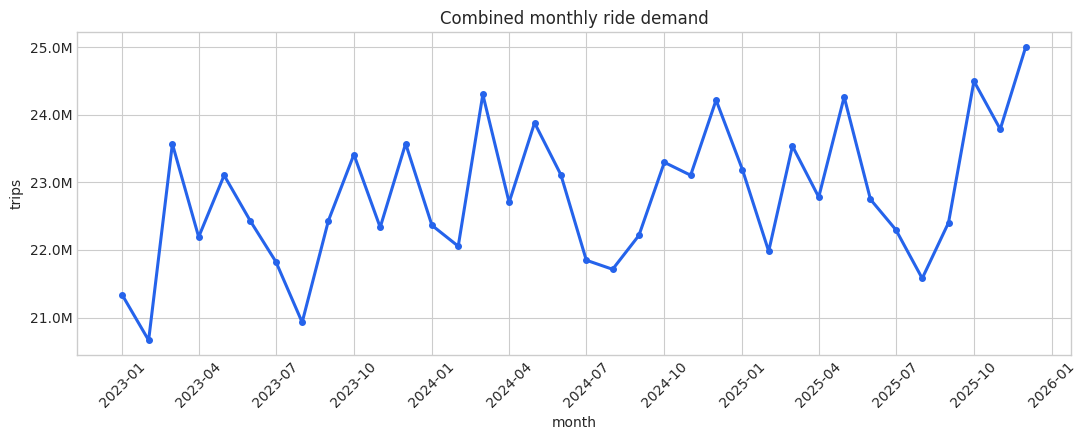

In [5]:
source_totals.orderBy("source_id").show(truncate=False)

combined_total = source_totals.agg(F.sum("total_trips").cast("long").alias("combined_total_trips"))
combined_total.show(truncate=False)

monthly_demand = (
    ml_df.groupBy("pickup_year", "pickup_month")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
    .withColumn(
        "month_start",
        F.to_date(F.concat_ws("-", F.col("pickup_year"), F.format_string("%02d", F.col("pickup_month")), F.lit("01"))),
    )
    .withColumn("year_month", F.date_format("month_start", "yyyy-MM"))
    .orderBy("month_start")
)
monthly_demand.show(40, truncate=False)
line_plot(
    monthly_demand,
    "month_start",
    "trip_count",
    "Combined monthly ride demand",
    "month",
    "trips",
    color="#2563eb",
    x_is_date=True,
)


## 6. ML Target Variable Distribution

The machine-learning target is `trip_count` in `nyc.taxi_demand_ml`. Each row represents hourly demand for one source and pickup zone. For modeling, the useful question is not only how many rows fall in each range, but also how much actual trip volume those rows represent.


+-------+---------------+-----------------+--------------+--------------+--------+
|ml_rows|mean_trip_count|stddev_trip_count|min_trip_count|max_trip_count|skewness|
+-------+---------------+-----------------+--------------+--------------+--------+
|9266295|88.56          |110.71           |1.0           |2623.0        |2.82    |
+-------+---------------+-----------------+--------------+--------------+--------+



+--------------+--------+----------+
|quantile_label|quantile|trip_count|
+--------------+--------+----------+
|min           |0.0     |1.0       |
|p25           |0.25    |11.0      |
|median        |0.5     |53.0      |
|p75           |0.75    |126.0     |
|p90           |0.9     |223.0     |
|p95           |0.95    |293.0     |
|p99           |0.99    |500.0     |
|max           |1.0     |2623.0    |
+--------------+--------+----------+

Plot sample rows: 186,061


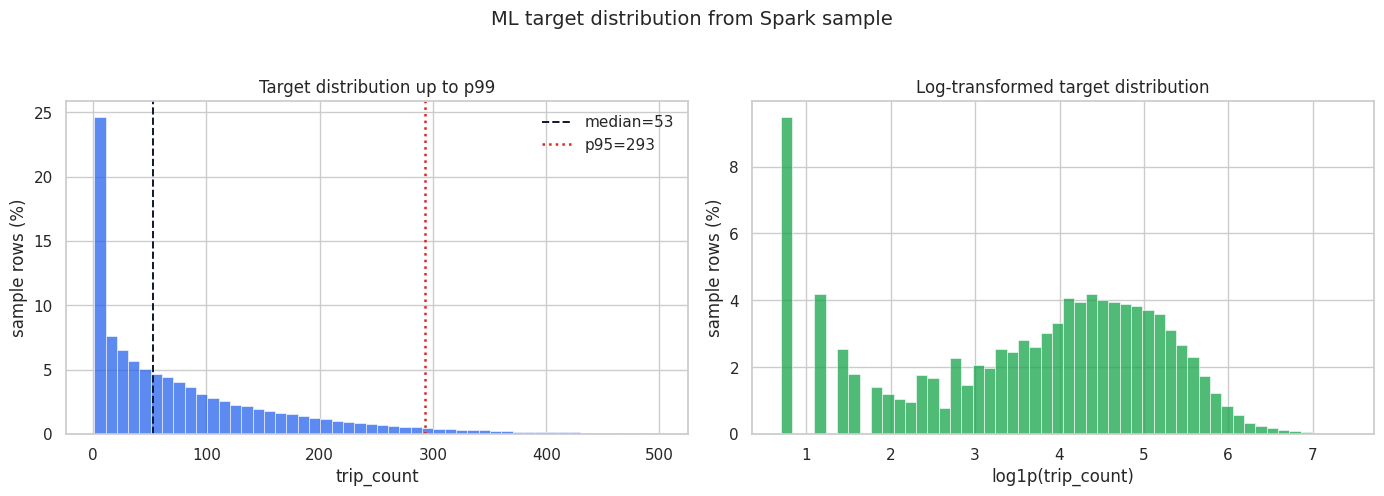

In [6]:
target_df = ml_df.select(F.col("trip_count").cast("double").alias("trip_count"))

# Full-table target statistics stay in Spark.
target_summary = target_df.agg(
    F.count("trip_count").alias("ml_rows"),
    F.round(F.mean("trip_count"), 2).alias("mean_trip_count"),
    F.round(F.stddev("trip_count"), 2).alias("stddev_trip_count"),
    F.min("trip_count").alias("min_trip_count"),
    F.max("trip_count").alias("max_trip_count"),
    F.round(F.skewness("trip_count"), 2).alias("skewness"),
)
target_summary.show(truncate=False)

quantile_probs = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
quantile_labels = ["min", "p25", "median", "p75", "p90", "p95", "p99", "max"]
quantile_values = target_df.approxQuantile("trip_count", quantile_probs, 0.001)

target_quantiles = spark.createDataFrame(
    [
        (label, float(prob), float(value))
        for label, prob, value in zip(quantile_labels, quantile_probs, quantile_values)
    ],
    ["quantile_label", "quantile", "trip_count"],
)
target_quantiles.show(truncate=False)

p50 = quantile_values[2]
p95 = quantile_values[5]
p99 = quantile_values[6]

try:
    import pandas as pd  # required by Spark .toPandas()
    import seaborn as sns
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "The target distribution chart uses a bounded Spark sample collected to Pandas for Seaborn. "
        "Rebuild and restart the Spark image so pandas and seaborn are available."
    ) from exc

if plt is None:
    print("Skipping chart: matplotlib is not installed in this kernel.")
else:
    target_sample_fraction = 0.02
    target_sample_limit = 200_000

    target_sample_pd = (
        target_df
        .withColumn("log_trip_count", F.log1p("trip_count"))
        .sample(False, target_sample_fraction, seed=42)
        .select("trip_count", "log_trip_count")
        .limit(target_sample_limit)
        .toPandas()
    )
    print(f"Plot sample rows: {len(target_sample_pd):,}")

    raw_plot_pd = target_sample_pd[target_sample_pd["trip_count"] <= p99]

    sns.set_theme(style="whitegrid", context="notebook")
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    sns.histplot(
        data=raw_plot_pd,
        x="trip_count",
        bins=50,
        stat="percent",
        ax=axes[0],
        color="#2563eb",
        edgecolor="white",
        linewidth=0.4,
    )
    axes[0].axvline(
        p50,
        color="#0f172a",
        linestyle="--",
        linewidth=1.4,
        label=f"median={p50:.0f}",
    )
    axes[0].axvline(
        p95,
        color="#dc2626",
        linestyle=":",
        linewidth=1.8,
        label=f"p95={p95:.0f}",
    )
    axes[0].set_title("Target distribution up to p99")
    axes[0].set_xlabel("trip_count")
    axes[0].set_ylabel("sample rows (%)")
    axes[0].legend(frameon=False)

    sns.histplot(
        data=target_sample_pd,
        x="log_trip_count",
        bins=50,
        stat="percent",
        ax=axes[1],
        color="#16a34a",
        edgecolor="white",
        linewidth=0.4,
    )
    axes[1].set_title("Log-transformed target distribution")
    axes[1].set_xlabel("log1p(trip_count)")
    axes[1].set_ylabel("sample rows (%)")

    fig.suptitle("ML target distribution from Spark sample", y=1.03, fontsize=14)
    plt.tight_layout()


### Modeling Takeaway

`trip_count` is right-skewed, with many low-demand rows and a small high-demand tail. For the ML section, this supports using both absolute-error and squared-error metrics, and it makes `log1p(trip_count)` worth testing for linear models. Tree-based models can still use the original target, but the tail should be watched in error analysis.


## 7. Combined Hour-of-Day and Weekday Patterns

These views show total demand across both Yellow Taxi and HVFHV. This is the better fit for citywide forecasting because it captures the full ride-demand pattern.


+-----------+----------+
|pickup_hour|trip_count|
+-----------+----------+
|0          |29165763  |
|1          |20306371  |
|2          |14449923  |
|3          |11407068  |
|4          |11489290  |
|5          |13396081  |
|6          |21086176  |
|7          |32148724  |
|8          |39661070  |
|9          |37891547  |
|10         |35710247  |
|11         |35643519  |
|12         |36799521  |
|13         |38138218  |
|14         |41134294  |
|15         |42257962  |
|16         |43437664  |
|17         |47769878  |
|18         |49817229  |
|19         |47723822  |
|20         |45050152  |
|21         |44406700  |
|22         |43479701  |
|23         |38262798  |
+-----------+----------+

+----------+-----------+----------+
|is_weekend|pickup_hour|trip_count|
+----------+-----------+----------+
|false     |0          |15563431  |
|false     |1          |9329982   |
|false     |2          |6142698   |
|false     |3          |5062654   |
|false     |4          |6569222   |
|false     

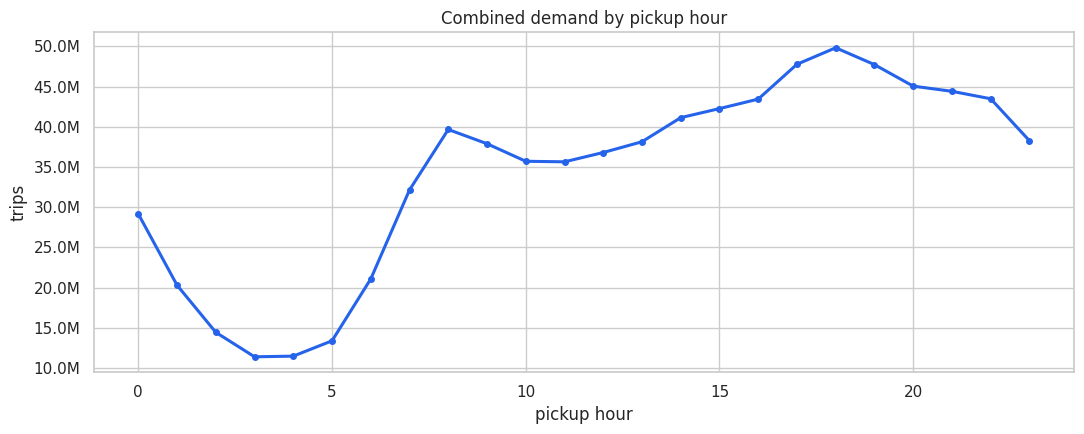

In [7]:
overall_hourly = eda["overall_hourly_demand"]
weekday_weekend = eda["weekday_weekend_demand"]
weekday_hourly = eda["weekday_hourly_demand"]

hourly_demand = (
    overall_hourly.groupBy("pickup_hour")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
    .orderBy("pickup_hour")
)
hourly_demand.show(24, truncate=False)
line_plot(
    hourly_demand,
    "pickup_hour",
    "trip_count",
    "Combined demand by pickup hour",
    "pickup hour",
    "trips",
    color="#2563eb",
)

weekday_weekend_by_hour = (
    weekday_weekend
    .groupBy("is_weekend", "pickup_hour")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
    .orderBy("is_weekend", "pickup_hour")
)
weekday_weekend_by_hour.show(48, truncate=False)


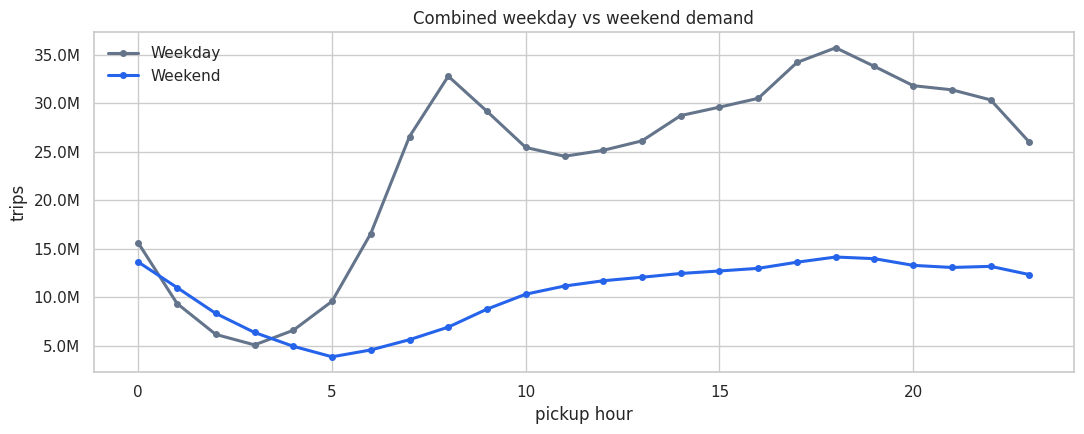

In [8]:
multi_line_plot(
    weekday_weekend_by_hour,
    "pickup_hour",
    "trip_count",
    "is_weekend",
    "Combined weekday vs weekend demand",
    "pickup hour",
    "trips",
    series_labels={False: "Weekday", True: "Weekend"},
    series_colors={False: "#64748b", True: "#2563eb"},
)


## 8. Combined Borough and Zone Demand

These geography views sum demand across both services. This shows where total ride demand is concentrated, instead of comparing service markets separately.


+-------------+----------+-----------+--------------+
|borough      |trip_count|total_trips|trip_share_pct|
+-------------+----------+-----------+--------------+
|Manhattan    |370868782 |820633718  |45.19         |
|Brooklyn     |189209326 |820633718  |23.06         |
|Queens       |160637519 |820633718  |19.57         |
|Bronx        |88797983  |820633718  |10.82         |
|Staten Island|10586312  |820633718  |1.29          |
|Unknown      |487362    |820633718  |0.06          |
|N/A          |45226     |820633718  |0.01          |
|EWR          |1208      |820633718  |0.0           |
+-------------+----------+-----------+--------------+



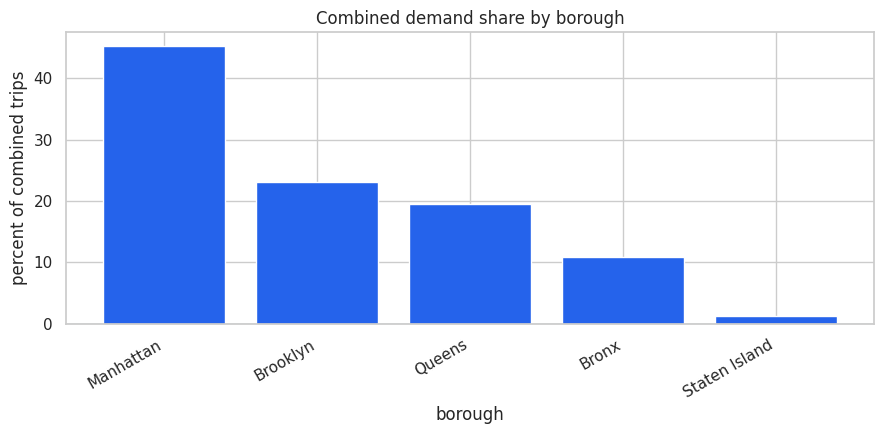

In [9]:
borough_hourly = eda["borough_hourly_demand"]

borough_demand = (
    borough_hourly
    .fillna({"borough": "Unknown"})
    .groupBy("borough")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
)
borough_total = borough_demand.agg(F.sum("trip_count").alias("total_trips"))
borough_share = (
    borough_demand.crossJoin(borough_total)
    .withColumn("trip_share_pct", F.round(F.col("trip_count") / F.col("total_trips") * 100, 2))
    .orderBy(F.desc("trip_count"))
)
borough_share.show(20, truncate=False)

major_boroughs = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]
major_borough_share = (
    borough_share
    .filter(F.col("borough").isin(major_boroughs))
    .orderBy(F.desc("trip_share_pct"))
)
bar_plot(
    major_borough_share,
    "borough",
    "trip_share_pct",
    "Combined demand share by borough",
    "borough",
    "percent of combined trips",
    color="#2563eb",
)


Combined top pickup zones from the EDA top-zone table
+-----------+---------+-------------------------+----------+
|location_id|borough  |zone                     |trip_count|
+-----------+---------+-------------------------+----------+
|132        |Queens   |JFK Airport              |18311808  |
|138        |Queens   |LaGuardia Airport        |17720678  |
|161        |Manhattan|Midtown Center           |13667762  |
|230        |Manhattan|Times Sq/Theatre District|12403013  |
|79         |Manhattan|East Village             |11728275  |
|68         |Manhattan|East Chelsea             |10776069  |
|234        |Manhattan|Union Sq                 |10507849  |
|164        |Manhattan|Midtown South            |9954802   |
|48         |Manhattan|Clinton East             |9784858   |
|61         |Brooklyn |Crown Heights North      |9327144   |
|249        |Manhattan|West Village             |8981381   |
|231        |Manhattan|TriBeCa/Civic Center     |8117653   |
|37         |Brooklyn |Bushwick

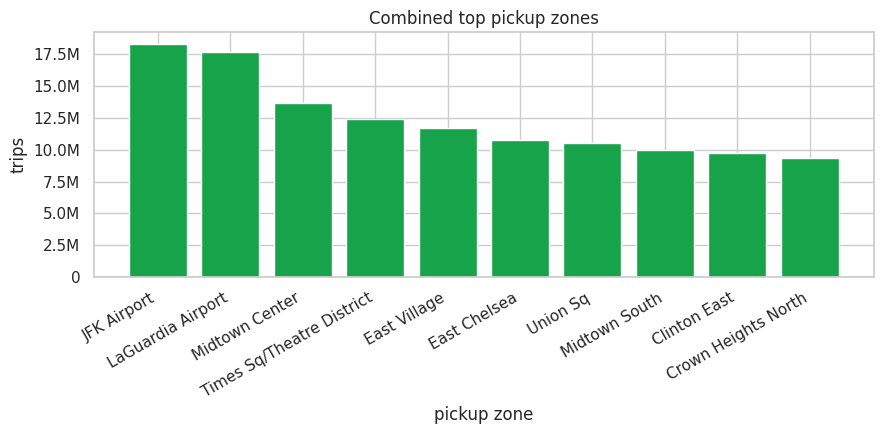

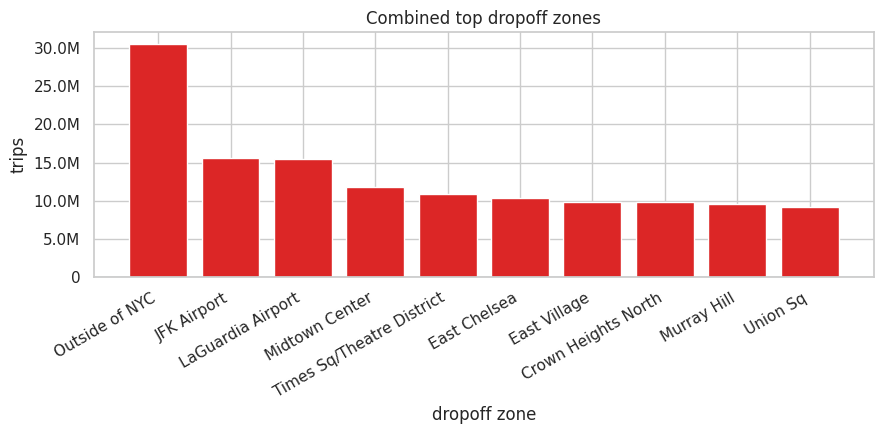

In [10]:
top_pickup = eda["top_pickup_zones"]
top_dropoff = eda["top_dropoff_zones"]

combined_top_pickup = (
    top_pickup
    .groupBy("location_id", "borough", "zone")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
    .orderBy(F.desc("trip_count"), F.asc("location_id"))
)
print("Combined top pickup zones from the EDA top-zone table")
combined_top_pickup.show(20, truncate=False)
bar_plot(
    combined_top_pickup.limit(10),
    "zone",
    "trip_count",
    "Combined top pickup zones",
    "pickup zone",
    "trips",
    color="#16a34a",
)

combined_top_dropoff = (
    top_dropoff
    .groupBy("location_id", "borough", "zone")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
    .orderBy(F.desc("trip_count"), F.asc("location_id"))
)
print("Combined top dropoff zones from the EDA top-zone table")
combined_top_dropoff.show(20, truncate=False)
bar_plot(
    combined_top_dropoff.limit(10),
    "zone",
    "trip_count",
    "Combined top dropoff zones",
    "dropoff zone",
    "trips",
    color="#dc2626",
)


## 9. Combined Trip Metrics by Hour

Trip metrics are aggregated across both services using trip-count weighted averages, so the combined line reflects the full ride-demand mix.


+-----------+----------+-------------------------+------------------+------------------+
|pickup_hour|trip_count|avg_trip_duration_seconds|avg_trip_miles    |avg_speed_mph     |
+-----------+----------+-------------------------+------------------+------------------+
|0          |29165763  |1041.9298993137947       |5.213369296287567 |15.73948802333748 |
|1          |20306371  |984.7839322939584        |5.0595919089629575|16.119698583759728|
|2          |14449923  |967.7570954530346        |5.1478714248511945|16.7053684583648  |
|3          |11407068  |999.5670267767317        |5.819703061645645 |18.324962177835697|
|4          |11489290  |1069.8385608684262       |6.954502507813791 |20.603802125283636|
|5          |13396081  |1120.9207838471566       |7.173719854635104 |20.365180421050002|
|6          |21086176  |1140.2055479855617       |6.191371234025564 |17.40320689630969 |
|7          |32148724  |1154.6125556336233       |5.021581309447938 |14.086292262174982|
|8          |39661070

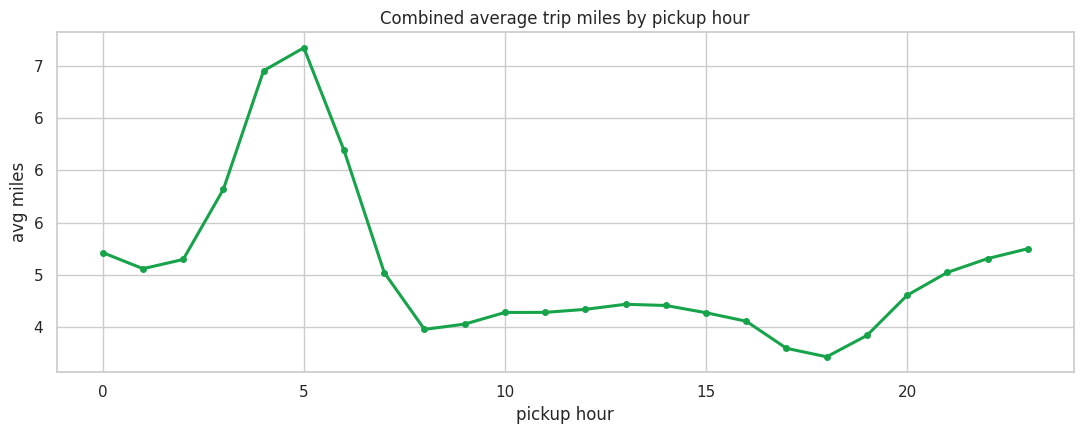

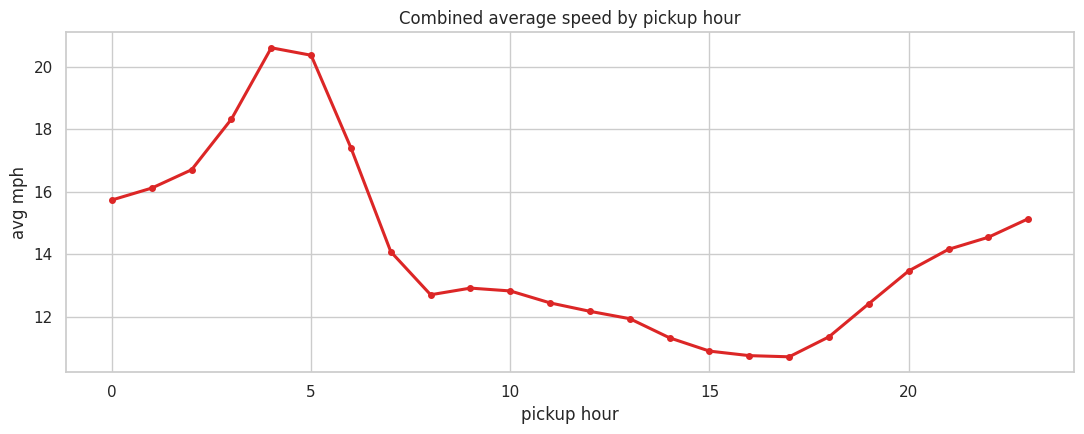

In [11]:
trip_metrics = eda["trip_metrics_by_hour"]

combined_trip_metrics = (
    trip_metrics
    .groupBy("pickup_hour")
    .agg(
        F.sum("trip_count").cast("long").alias("trip_count"),
        (F.sum(F.col("avg_trip_duration_seconds") * F.col("trip_count")) / F.sum("trip_count")).alias("avg_trip_duration_seconds"),
        (F.sum(F.col("avg_trip_miles") * F.col("trip_count")) / F.sum("trip_count")).alias("avg_trip_miles"),
        (F.sum(F.col("avg_speed_mph") * F.col("trip_count")) / F.sum("trip_count")).alias("avg_speed_mph"),
    )
    .orderBy("pickup_hour")
)
combined_trip_metrics.show(24, truncate=False)
line_plot(
    combined_trip_metrics,
    "pickup_hour",
    "avg_trip_miles",
    "Combined average trip miles by pickup hour",
    "pickup hour",
    "avg miles",
    color="#16a34a",
)
line_plot(
    combined_trip_metrics,
    "pickup_hour",
    "avg_speed_mph",
    "Combined average speed by pickup hour",
    "pickup hour",
    "avg mph",
    color="#dc2626",
)


## 10. Combined Holiday and Special-Day Impact

A single holiday-versus-regular-day comparison is too sensitive to the chosen date. This section compares major holidays against a baseline made from non-holiday days with the same year, month, and weekday, after summing Yellow Taxi and HVFHV together.


+----------------+-----------+-------------+------------------+------------------+---------------+
|holiday_name    |pickup_date|holiday_trips|baseline_avg_trips|baseline_day_count|pct_vs_baseline|
+----------------+-----------+-------------+------------------+------------------+---------------+
|Christmas Day   |2023-12-25 |490236       |707142.33         |3                 |-30.67         |
|Christmas Day   |2024-12-25 |551407       |824564.33         |3                 |-33.13         |
|Christmas Day   |2025-12-25 |566664       |882777.33         |3                 |-35.81         |
|Independence Day|2023-07-04 |541299       |672521.0          |3                 |-19.51         |
|Independence Day|2024-07-04 |608090       |738590.0          |3                 |-17.67         |
|Independence Day|2025-07-04 |622086       |790867.0          |3                 |-21.34         |
|New Year's Day  |2023-01-01 |697642       |710579.75         |4                 |-1.82          |
|New Year'

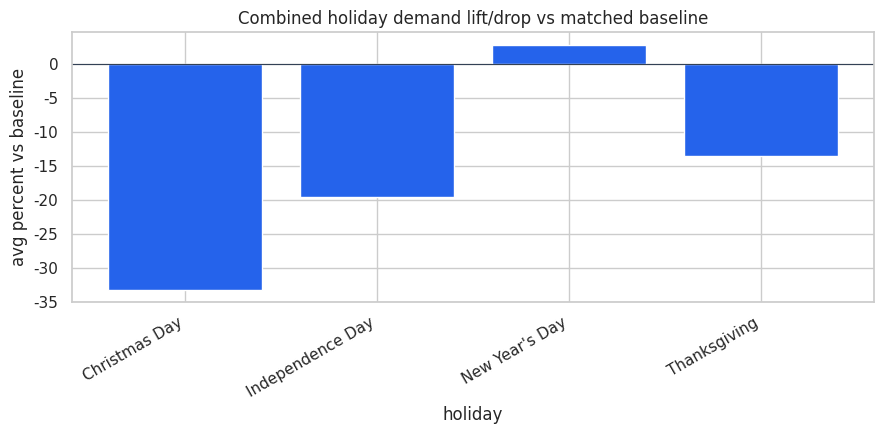

In [12]:
holiday_rows = [
    ("New Year's Day", "2023-01-01"),
    ("New Year's Day", "2024-01-01"),
    ("New Year's Day", "2025-01-01"),
    ("Independence Day", "2023-07-04"),
    ("Independence Day", "2024-07-04"),
    ("Independence Day", "2025-07-04"),
    ("Thanksgiving", "2023-11-23"),
    ("Thanksgiving", "2024-11-28"),
    ("Thanksgiving", "2025-11-27"),
    ("Christmas Day", "2023-12-25"),
    ("Christmas Day", "2024-12-25"),
    ("Christmas Day", "2025-12-25"),
]

special_dates = spark.createDataFrame(
    holiday_rows,
    ["holiday_name", "date_string"],
).withColumn("pickup_date", F.to_date("date_string"))

all_special_dates = special_dates.select("pickup_date").distinct()

daily_demand = (
    overall_hourly
    .groupBy("pickup_date", "pickup_year", "pickup_month", "pickup_day_of_week")
    .agg(F.sum("trip_count").cast("long").alias("trip_count"))
)

holiday_daily = daily_demand.join(
    special_dates.select("holiday_name", "pickup_date"),
    "pickup_date",
    "inner",
)

baseline_daily = daily_demand.join(all_special_dates, "pickup_date", "left_anti")

baseline_comparison = (
    holiday_daily.alias("holiday")
    .join(
        baseline_daily.alias("baseline"),
        (F.col("holiday.pickup_year") == F.col("baseline.pickup_year"))
        & (F.col("holiday.pickup_month") == F.col("baseline.pickup_month"))
        & (F.col("holiday.pickup_day_of_week") == F.col("baseline.pickup_day_of_week")),
        "left",
    )
    .groupBy(
        F.col("holiday.holiday_name").alias("holiday_name"),
        F.col("holiday.pickup_date").alias("pickup_date"),
        F.col("holiday.trip_count").alias("holiday_trips"),
    )
    .agg(
        F.round(F.avg(F.col("baseline.trip_count")), 2).alias("baseline_avg_trips"),
        F.count(F.col("baseline.trip_count")).alias("baseline_day_count"),
    )
    .withColumn(
        "pct_vs_baseline",
        F.round((F.col("holiday_trips") - F.col("baseline_avg_trips")) / F.col("baseline_avg_trips") * 100, 2),
    )
    .orderBy("holiday_name", "pickup_date")
)

baseline_comparison.show(40, truncate=False)

holiday_summary = (
    baseline_comparison
    .groupBy("holiday_name")
    .agg(
        F.round(F.avg("holiday_trips"), 2).alias("avg_holiday_trips"),
        F.round(F.avg("baseline_avg_trips"), 2).alias("avg_baseline_trips"),
        F.round(F.avg("pct_vs_baseline"), 2).alias("avg_pct_vs_baseline"),
    )
    .orderBy("holiday_name")
)
holiday_summary.show(truncate=False)

bar_plot(
    holiday_summary,
    "holiday_name",
    "avg_pct_vs_baseline",
    "Combined holiday demand lift/drop vs matched baseline",
    "holiday",
    "avg percent vs baseline",
    color="#2563eb",
)


## 11. Stop Spark

Run this when you are finished with the notebook session.


In [13]:
spark.stop()
